<a href="https://colab.research.google.com/github/AlvaroAla/TE-IA/blob/main/aula0_6_positional_encoding_interactive.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>


# Positional Encoding – Interface Interativa

Este notebook reproduz visualizações clássicas de **Positional Encoding sinusoidal**
(Vaswani et al., 2017) e permite exploração interativa via **ipywidgets**.

Você pode:
- Ajustar o comprimento da sequência
- Ajustar a dimensão do embedding (`d_model`)
- Visualizar o heatmap do PE
- Visualizar a matriz de similaridade entre posições


In [1]:

import numpy as np
import matplotlib.pyplot as plt

import ipywidgets as widgets
from IPython.display import display, clear_output


## Implementação do Positional Encoding

In [2]:

def positional_encoding(seq_len, d_model):
    pe = np.zeros((seq_len, d_model))
    position = np.arange(seq_len)[:, np.newaxis]

    div_term = np.exp(
        np.arange(0, d_model, 2) * (-np.log(10000.0) / d_model)
    )

    pe[:, 0::2] = np.sin(position * div_term)
    pe[:, 1::2] = np.cos(position * div_term)

    return pe


## Funções de Similaridade

In [3]:

def dot_product_similarity(pe):
    return pe @ pe.T


def cosine_similarity(pe):
    pe_norm = pe / np.linalg.norm(pe, axis=1, keepdims=True)
    return pe_norm @ pe_norm.T


## Função de Plot Interativa

In [4]:

def plot_interactive(seq_len, d_model, view_type, similarity_type):
    clear_output(wait=True)

    pe = positional_encoding(seq_len, d_model)

    plt.figure(figsize=(8, 6))

    if view_type == "Positional Encoding":
        im = plt.imshow(pe, aspect="auto", cmap="viridis")
        plt.title("Positional Encoding Heatmap")
        plt.xlabel("Embedding Dimension")
        plt.ylabel("Position")
        plt.colorbar(im, label="Value")

    else:
        if similarity_type == "Dot Product":
            sim = dot_product_similarity(pe)
            vmin, vmax = None, None
        else:
            sim = cosine_similarity(pe)
            vmin, vmax = 0, 1

        im = plt.imshow(sim, cmap="Blues", vmin=vmin, vmax=vmax)
        plt.title(f"{similarity_type} Similarity Between Positions")
        plt.xlabel("Position")
        plt.ylabel("Position")
        plt.colorbar(im, label="Similarity")

    plt.tight_layout()
    plt.show()


## Interface Interativa

In [5]:

seq_len_slider = widgets.IntSlider(
    value=50, min=10, max=200, step=10, description="Seq Len"
)

d_model_slider = widgets.IntSlider(
    value=64, min=16, max=256, step=16, description="d_model"
)

view_selector = widgets.Dropdown(
    options=["Positional Encoding", "Similarity Matrix"],
    value="Positional Encoding",
    description="View"
)

similarity_selector = widgets.Dropdown(
    options=["Dot Product", "Cosine"],
    value="Dot Product",
    description="Similarity"
)

ui = widgets.VBox([
    seq_len_slider,
    d_model_slider,
    view_selector,
    similarity_selector
])

out = widgets.interactive_output(
    plot_interactive,
    {
        "seq_len": seq_len_slider,
        "d_model": d_model_slider,
        "view_type": view_selector,
        "similarity_type": similarity_selector
    }
)

display(ui, out)


Output()

In [6]:
import numpy as np
import matplotlib.pyplot as plt

# Positional Encoding
def positional_encoding(seq_len, d_model):
    pe = np.zeros((seq_len, d_model))
    position = np.arange(seq_len)[:, np.newaxis]
    div_term = np.exp(np.arange(0, d_model, 2) * (-np.log(10000.0) / d_model))

    pe[:, 0::2] = np.sin(position * div_term)
    pe[:, 1::2] = np.cos(position * div_term)

    return pe

# Similaridades
def dot_product_similarity(pe):
    return pe @ pe.T

def cosine_similarity(pe):
    pe_norm = pe / np.linalg.norm(pe, axis=1, keepdims=True)
    return pe_norm @ pe_norm.T

# Função para gerar gráficos
def gerar_grafico(seq_len, d_model, modo="pe", similaridade="cosine"):
    pe = positional_encoding(seq_len, d_model)

    plt.figure(figsize=(7,5))

    if modo == "pe":
        plt.imshow(pe, aspect="auto", cmap="viridis")
        plt.title(f"Positional Encoding | seq_len={seq_len}, d_model={d_model}")
        plt.xlabel("Embedding Dimension")
        plt.ylabel("Position")
        plt.colorbar()

    else:
        if similaridade == "dot":
            sim = dot_product_similarity(pe)
            titulo = "Dot Product Similarity"
            plt.imshow(sim, cmap="Blues")
        else:
            sim = cosine_similarity(pe)
            titulo = "Cosine Similarity"
            plt.imshow(sim, cmap="Blues", vmin=0, vmax=1)

        plt.title(f"{titulo} | seq_len={seq_len}, d_model={d_model}")
        plt.xlabel("Position")
        plt.ylabel("Position")
        plt.colorbar()

    plt.tight_layout()
    plt.show()

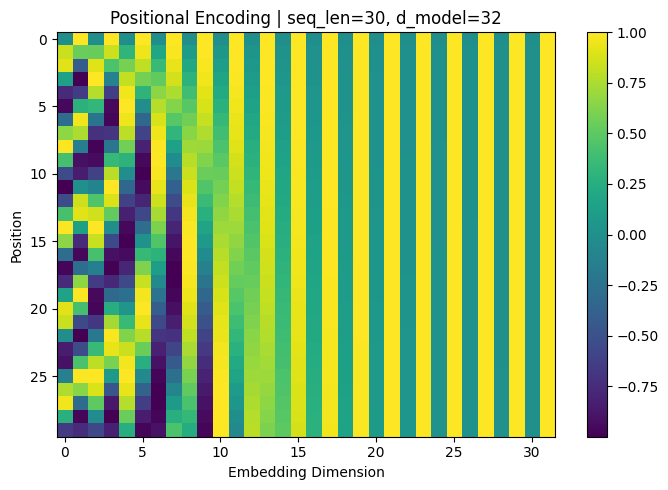

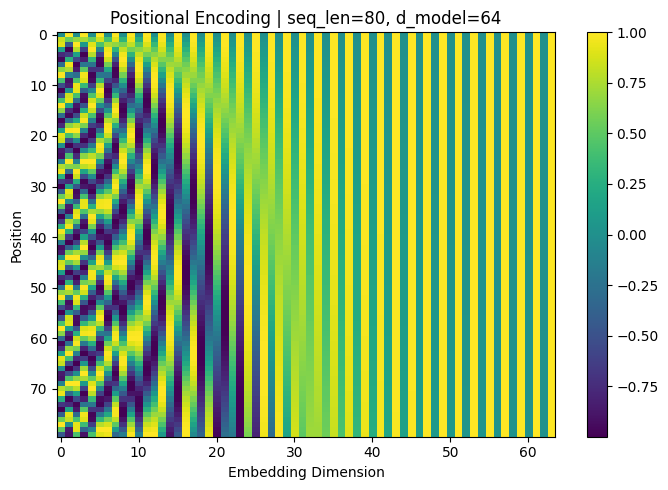

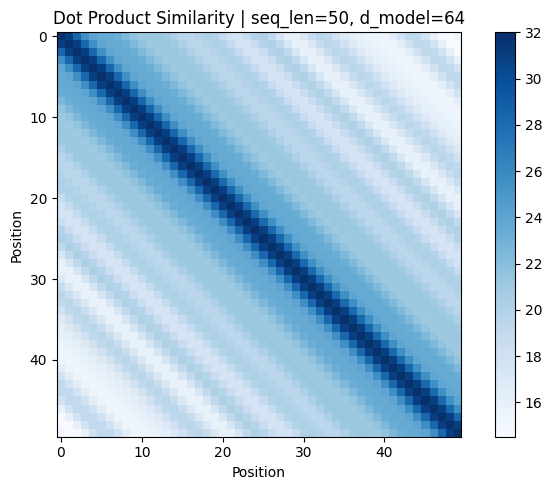

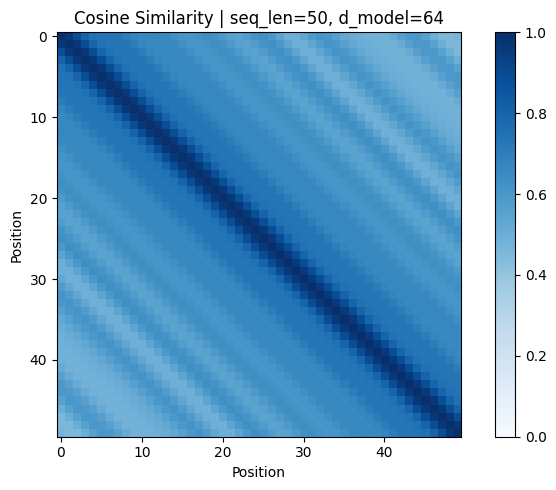

In [7]:
# Teste 1 - Positional Encoding menor
gerar_grafico(30, 32, modo="pe")

# Teste 2 - Positional Encoding maior
gerar_grafico(80, 64, modo="pe")

# Teste 3 - Similaridade (dot product)
gerar_grafico(50, 64, modo="similaridade", similaridade="dot")

# Teste 4 - Similaridade (cosine)
gerar_grafico(50, 64, modo="similaridade", similaridade="cosine")

# Atividade – Positional Encoding

O objetivo desta atividade foi entender como funciona o **Positional Encoding sinusoidal**, utilizado em modelos Transformer para representar a posição dos elementos em uma sequência.

Como o Transformer não processa os dados de forma sequencial como RNNs, ele precisa de uma forma de identificar a posição de cada token. Para isso, é utilizado o Positional Encoding, que gera vetores usando funções **seno e cosseno** em diferentes frequências.

No notebook, foi possível visualizar isso através de gráficos (heatmaps). Cada linha representa uma posição da sequência e cada coluna representa uma dimensão do embedding.

Ao testar diferentes valores de `seq_len` e `d_model`, foi possível observar que:

- aumentando `seq_len`, aparecem mais posições no gráfico;
- aumentando `d_model`, aparecem mais padrões de frequência;
- o mapa de calor mostra padrões ondulatórios devido ao seno e cosseno;
- a matriz de similaridade mostra quais posições são mais parecidas entre si.

Assim, foi possível entender como o Positional Encoding ajuda o Transformer a representar a ordem dos elementos em uma sequência.